In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('CRH','BRK-B'), 
         ('CRH','JPM'), 
         ('CRH','LLY'), 
         ('TDG','BRK-B'), 
         ('TDG', 'JPM'),
         ('TDG', 'LLY'), 
         ('NEM','BRK-B'), 
         ('NEM', 'JPM'), 
         ('NEM','LLY')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.6s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

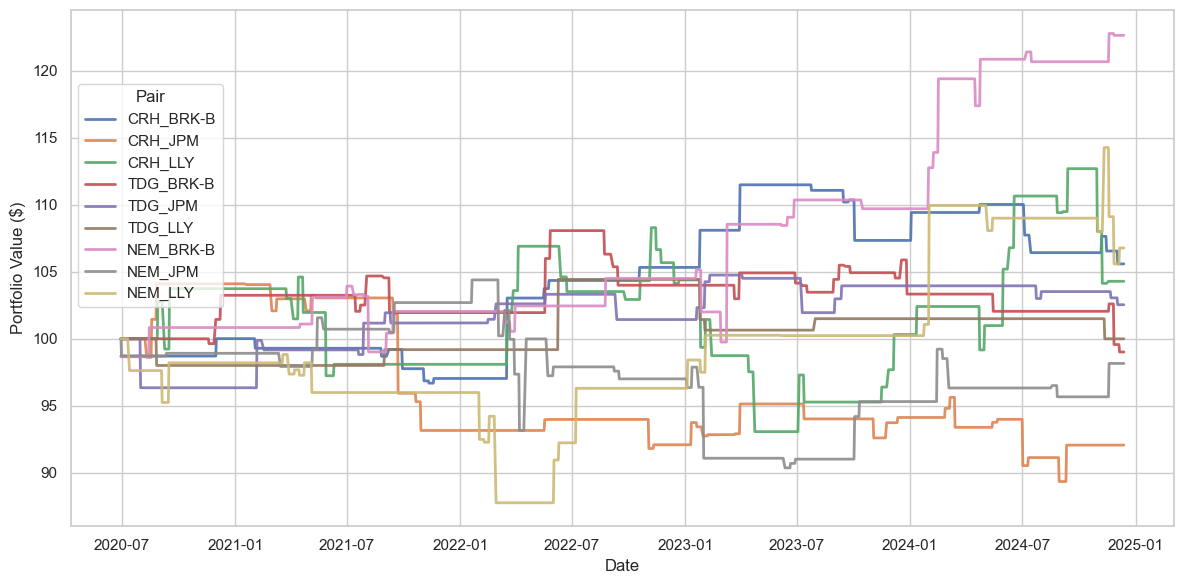

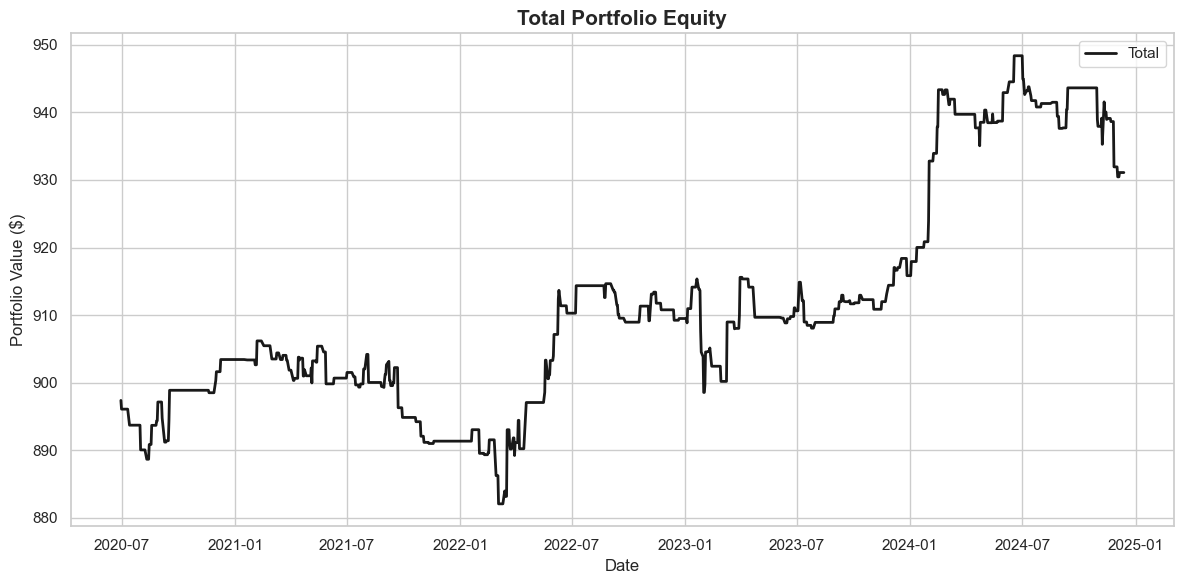

Summary
CRH_BRK-B: Final Value = $105.59, Total Return = 6.97%, Trades = 26
CRH_JPM: Final Value = $92.06, Total Return = -7.94%, Trades = 36
CRH_LLY: Final Value = $104.29, Total Return = 4.29%, Trades = 44
TDG_BRK-B: Final Value = $99.02, Total Return = -0.98%, Trades = 29
TDG_JPM: Final Value = $102.54, Total Return = 2.54%, Trades = 23
TDG_LLY: Final Value = $100.00, Total Return = -0.00%, Trades = 7
NEM_BRK-B: Final Value = $122.66, Total Return = 24.33%, Trades = 32
NEM_JPM: Final Value = $98.16, Total Return = -1.84%, Trades = 34
NEM_LLY: Final Value = $106.78, Total Return = 6.78%, Trades = 29

Total Portfolio Performance
Initial Portfolio Value: $897.37
Final Portfolio Value:   $931.10
Total Return:            3.76%

Sharpe Ratios
CRH_BRK-B: Sharpe Ratio = 0.37
CRH_JPM: Sharpe Ratio = -0.33
CRH_LLY: Sharpe Ratio = 0.15
TDG_BRK-B: Sharpe Ratio = -0.04
TDG_JPM: Sharpe Ratio = 0.18
TDG_LLY: Sharpe Ratio = 0.02
NEM_BRK-B: Sharpe Ratio = 0.80
NEM_JPM: Sharpe Ratio = -0.03
NEM_LLY: 

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)